In [ ]:
!pip install qiskit qiskit-aer --quiet
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, entropy,Kraus
import numpy as np


Step 1 | S(R) = 1.0000
Step 2 | S(R) = 1.9997
Step 3 | S(R) = 2.9990
Step 4 | S(R) = 3.9946
Step 5 | S(R) = 4.9790
Step 6 | S(R) = 5.9138
Step 7 | S(R) = 6.6427
Step 8 | S(R) = 6.6433
Step 9 | S(R) = 5.9094
Step 10 | S(R) = 4.9770
Step 11 | S(R) = 3.9941


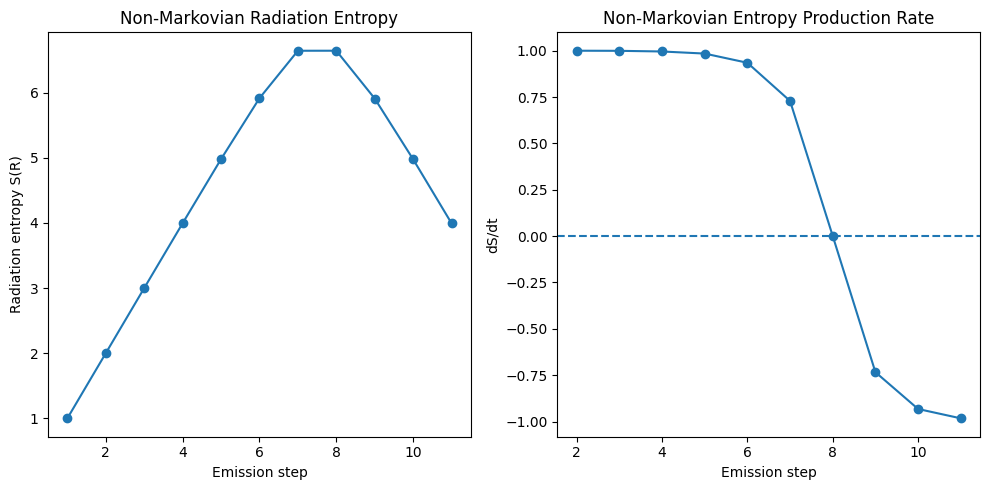

Step 1 | S(R) = 0.9996
Step 2 | S(R) = 1.9993
Step 3 | S(R) = 2.9982
Step 4 | S(R) = 3.9939
Step 5 | S(R) = 4.9785
Step 6 | S(R) = 5.9092
Step 7 | S(R) = 6.6393
Step 8 | S(R) = 6.6377
Step 9 | S(R) = 5.9064
Step 10 | S(R) = 4.9778
Step 11 | S(R) = 3.9943


In [ ]:


# -----------------------------
# PARAMETERS
# -----------------------------

N_BH = 12      # black hole qubits
N_ENV = 3       # environment qubits (finite bath)
SCRAMBLE_DEPTH = 5

TOTAL_QUBITS = N_BH + N_ENV


# -----------------------------
# SCRAMBLING (chaotic dynamics)
# -----------------------------

def scramble_black_hole(qc, bh):
    """
    Chaotic fast-scrambling unitary.
    Mimics Haar random circuit using layered local + global entanglement.
    Increased complexity for more chaotic behavior by incorporating diverse
    gate types and entanglement patterns.
    """

    LAYERS = 20 # Increased layers for more chaotic behavior

    for _ in range(LAYERS):

        # --- random single-qubit rotations (local chaos) ---
        # Using rx, ry, rz for diverse random single-qubit operations
        for q in bh:
            qc.rx(np.random.uniform(0, 2*np.pi), q)
            qc.ry(np.random.uniform(0, 2*np.pi), q)
            qc.rz(np.random.uniform(0, 2*np.pi), q)

        # --- diverse nearest-neighbour entanglement (local spreading) ---
        if len(bh) > 1:
            for i in range(len(bh)-1):
                qc.cx(bh[i], bh[i+1]) # Original CNOT
                qc.cz(bh[i], bh[i+1]) # Added CZ for more diversity
                qc.cy(bh[i+1], bh[i]) # Added CY with swapped control/target for diversity

        # --- diverse long-range entanglement (global scrambling) ---
        if len(bh) > 1: # Ensure there are at least 2 qubits for long-range interactions
            # Original long-range CZ pattern
            for i in range(len(bh)//2):
                qc.cz(bh[i], bh[-(i+1)])

            # Additional long-range connections from user's suggestion
            if len(bh) > 3: # Need at least 4 qubits for these specific connections
                qc.cx(bh[0], bh[-1]) # CNOT between first and last qubit
                qc.cy(bh[1], bh[-2]) # CY between second and second-to-last
                qc.cz(bh[0], bh[-2]) # CZ between first and second-to-last

        # --- random SWAP layer (operator growth) ---
        # This helps in quickly spreading entanglement
        for i in range(0, len(bh)-1, 2):
            qc.swap(bh[i], bh[i+1])



def markovian_decohere(rho, qubit, gamma=0.35):
    """
    Apply phase damping channel (memoryless bath).
    Destroys quantum correlations irreversibly.
    """

    K0 = np.array([[1, 0],
                   [0, np.sqrt(1-gamma)]])

    K1 = np.array([[0, 0],
                   [0, np.sqrt(gamma)]])

    channel = Kraus([K0, K1])

    return rho.evolve(channel, [qubit])


# -----------------------------
# ENVIRONMENT DYNAMICS
# -----------------------------

def evolve_environment(qc, env):
    """
    Environment self-interaction (stores memory).
    Introduced more diverse and random operations for environment evolution.
    """
    if len(env) < 2:
        return

    for i in range(len(env)-1):
        qc.cx(env[i], env[i+1])
        qc.cz(env[i], env[i+1]) # Added CZ for more environmental entanglement
        qc.rx(np.random.uniform(0, 2*np.pi), env[i]) # Random angles
        qc.ry(np.random.uniform(0, 2*np.pi), env[i+1]) # Random angles
        qc.rz(np.random.uniform(0, 2*np.pi), env[i]) # Added RZ for more diversity


# -----------------------------
# BH-ENV COUPLING
# -----------------------------

#---------------- Markovian evaporation-----------
def run_markovian_evaporation():

    qc = QuantumCircuit(N_BH)
    rho = DensityMatrix.from_instruction(qc)

    bh = list(range(N_BH))
    radiation = []

    entropies = []
    steps = []

    step = 0

    while len(bh) > 1:

        step += 1

        # scrambling (same chaos as NM case)
        scramble_black_hole(qc, bh)

        rho = rho.evolve(qc)

        # emit qubit
        emitted = bh.pop(0)
        radiation.append(emitted)

        # MARKOVIAN STEP: bath forgets immediately
        rho = markovian_decohere(rho, emitted)

        # compute radiation entropy
        rho_R = partial_trace(rho, bh)
        S_R = entropy(rho_R, base=2)

        entropies.append(S_R)
        steps.append(step)

        print(f"[Markovian] Step {step} | S(R) = {S_R:.4f}")

    return steps, entropies
#-----------NM-----------------------
def bh_environment_interaction(qc, bh, env):
    """Information exchange between system and bath"""
    for b in bh:
        for e in env:
            qc.cz(b, e)
            qc.rx(np.pi/8, b)
            qc.ry(np.pi/8, e)


# -----------------------------
# SIMULATION
# -----------------------------

def run_evaporation():

    qc = QuantumCircuit(TOTAL_QUBITS)
    state = Statevector.from_instruction(qc)

    bh = list(range(N_BH))
    env = list(range(N_BH, TOTAL_QUBITS))
    radiation = []

    entropies = []
    steps = []

    step = 0

    while len(bh) > 1:

        step += 1

        # 1. BH scrambling
        scramble_black_hole(qc, bh)

        # 2. environment evolves
        evolve_environment(qc, env)

        # 3. BH <-> environment interaction
        bh_environment_interaction(qc, bh, env)

        # update global state
        state = Statevector.from_instruction(qc)

        # 4. emission
        emitted = bh.pop(0)
        radiation.append(emitted)

        # 5. compute radiation entropy
        trace_out = bh + env
        rho_R = partial_trace(state, trace_out)
        S_R = entropy(rho_R, base=2)

        entropies.append(S_R)
        steps.append(step)

        print(f"Step {step} | S(R) = {S_R:.4f}")

    return steps, entropies


# -----------------------------
# MAIN
# -----------------------------

if __name__ == "__main__":

    # Run Non-Markovian evaporation and plot its characteristics
    steps_nm_single_run, entropy_R_single_run = run_evaporation()

    # entropy production rate
    dS = np.diff(entropy_R_single_run)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.plot(steps_nm_single_run, entropy_R_single_run, 'o-')
    plt.xlabel("Emission step")
    plt.ylabel("Radiation entropy S(R)")
    plt.title("Non-Markovian Radiation Entropy") # Added "Non-Markovian" for clarity

    plt.subplot(1,2,2)
    plt.plot(steps_nm_single_run[1:], dS, 'o-')
    plt.axhline(0, linestyle='--')
    plt.xlabel("Emission step")
    plt.ylabel("dS/dt")
    plt.title("Non-Markovian Entropy Production Rate") # Added "Non-Markovian" for clarity

    plt.tight_layout()
    plt.show()

    # Run both Markovian and Non-Markovian evaporation and compare them
    steps_nm_comp, S_nm_comp = run_evaporation()
    steps_m_comp, S_m_comp = run_markovian_evaporation()

    plt.figure(figsize=(8,5))

    plt.plot(steps_nm_comp, S_nm_comp, 'o-', label="Non-Markovian (finite bath)")
    plt.plot(steps_m_comp, S_m_comp, 's--', label="Markovian (memoryless bath)")

    plt.xlabel("Emission step")
    plt.ylabel("Radiation entropy")
    plt.title("Comparison: Markovian vs Non-Markovian Black Hole Evaporation") # Updated title for clarity
    plt.legend()
    plt.grid()
    plt.show()
